# Naive Bayes: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Naive Bayes** in Python.

### Concept Overview
A probabilistic classification algorithm based on Bayes' Theorem that assumes strong independence between features.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
P(C_k | \mathbf{x}) = \frac{P(\mathbf{x} | C_k) P(C_k)}{P(\mathbf{x})} \quad \text{where Naive assumption is } P(\mathbf{x}|C_k) = \prod_{i=1}^n P(x_i | C_k)
$$

### Real-World Analogy
**Analogy:** Deciding if it will rain based on temperature and wind, assuming they operate completely independently.

### Worked Example
**Worked Example:** Classifying email as spam. If words 'urgent' and 'free' appear, Naive Bayes computes probability: P(Spam|words) proportional to P('urgent'|Spam) * P('free'|Spam) * P(Spam) and compares it to the Non-Spam probability to choose the highest.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of spam classification dataset
from sklearn.datasets import make_classification
np.random.seed(42)
X_raw, y_raw = make_classification(n_samples=400, n_features=3, n_informative=3,
                                  n_redundant=0, n_classes=2, weights=[0.7, 0.3],
                                  class_sep=1.1, random_state=42)
df = pd.DataFrame({
    'WordCount': np.round(np.clip(X_raw[:, 0] * 50 + 150, 10, 500), 0),
    'ContainsUrgentWords': np.where(X_raw[:, 1] > 0.3, 1, 0),
    'ExclamationCount': np.round(np.clip(X_raw[:, 2] * 3 + 2, 0, 15), 0),
    'Spam': y_raw
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WordCount            400 non-null    float64
 1   ContainsUrgentWords  400 non-null    int64  
 2   ExclamationCount     400 non-null    float64
 3   Spam                 400 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 12.6 KB
        WordCount  ContainsUrgentWords  ExclamationCount        Spam
count  400.000000           400.000000        400.000000  400.000000
mean   129.215000             0.195000          3.740000    0.302500
std     72.265618             0.396697          3.019137    0.459916
min     10.000000             0.000000          0.000000    0.000000
25%     72.750000             0.000000          0.000000    0.000000
50%    122.000000             0.000000          4.000000    0.000000
75%    186.250000             0.000000

## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 WordCount              0
ContainsUrgentWords    0
ExclamationCount       0
Spam                   0
dtype: int64
Duplicate count: 46


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

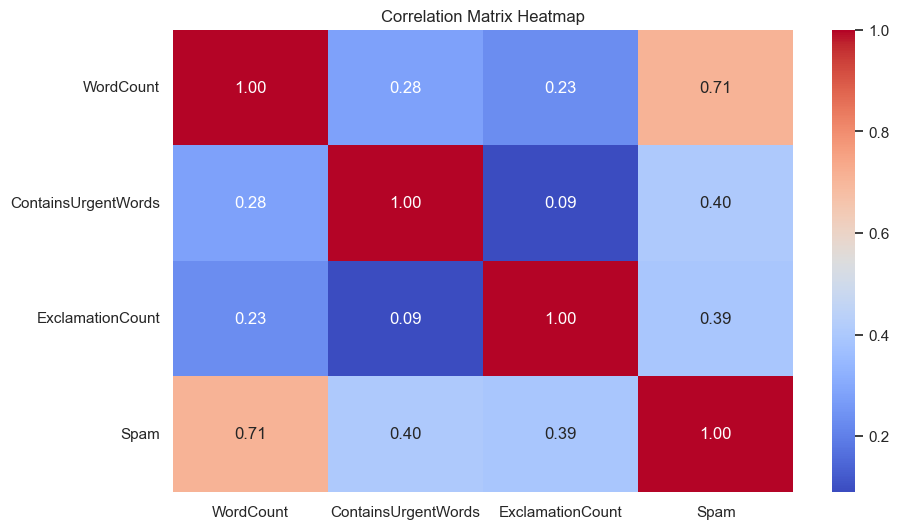

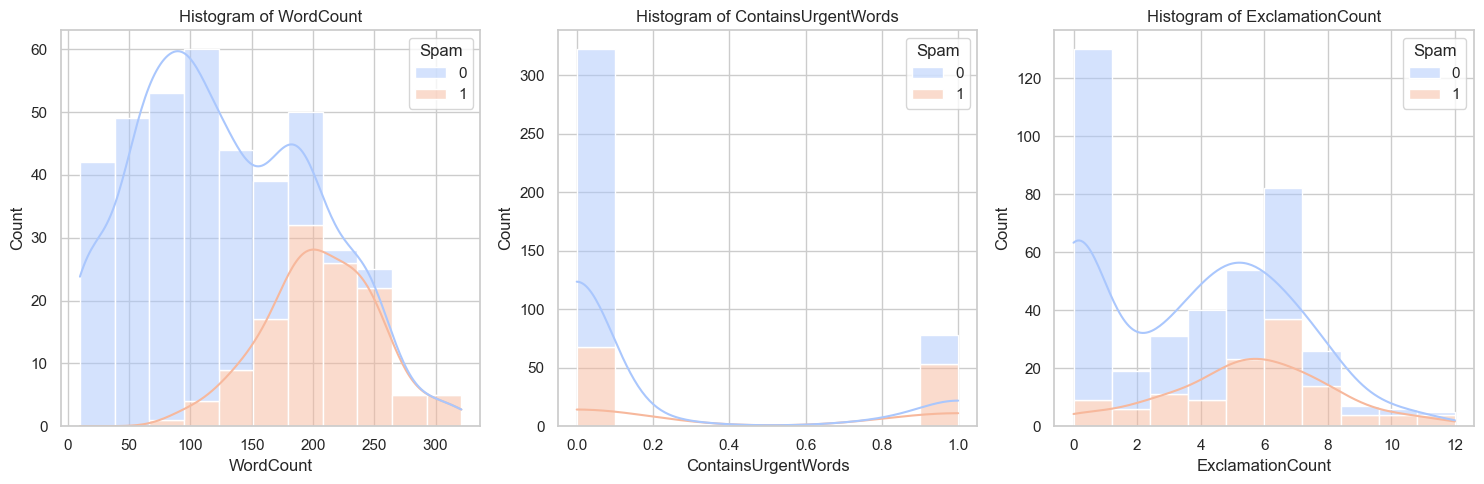

G:\Temp\ipykernel_17688\1348028533.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')


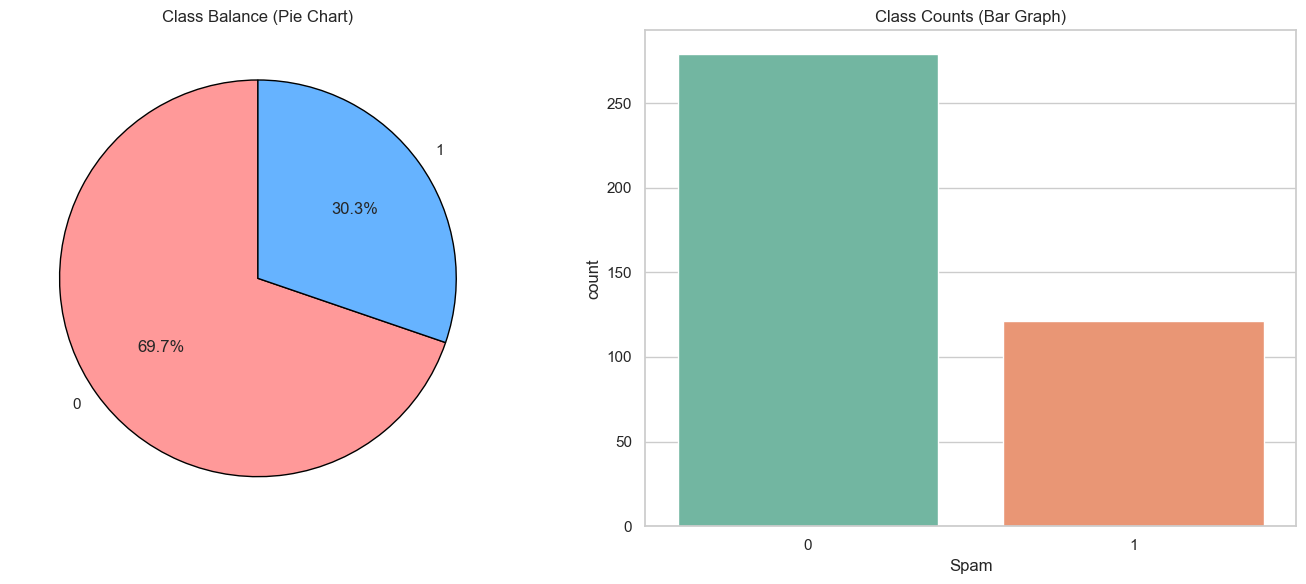

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 1. Feature Histograms (Continuous distributions colored by class)
X_cols = df.columns[:-1]
target_col = df.columns[-1]
fig, axes = plt.subplots(1, len(X_cols), figsize=(5 * len(X_cols), 5))
if len(X_cols) == 1:
    sns.histplot(data=df, x=X_cols[0], hue=target_col, kde=True, ax=axes, multiple='stack', palette='coolwarm')
    axes.set_title(f'Histogram of {X_cols[0]}')
else:
    for idx, col in enumerate(X_cols):
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[idx], multiple='stack', palette='coolwarm')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

# 2. Class Balance Pie Chart and Bar Graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Pie chart
class_counts = df[target_col].value_counts()
axes[0].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff', '#99ff99'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Class Balance (Pie Chart)')
# Bar chart
sns.countplot(data=df, x=target_col, ax=axes[1], palette='Set2')
axes[1].set_title('Class Counts (Bar Graph)')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (280, 3), Test size: (120, 3)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = GaussianNB()
model.fit(X_train, y_train)
print("Naive Bayes model trained.")

Naive Bayes model trained.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Accuracy: 0.9416666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        79
           1       0.89      0.95      0.92        41

    accuracy                           0.94       120
   macro avg       0.93      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

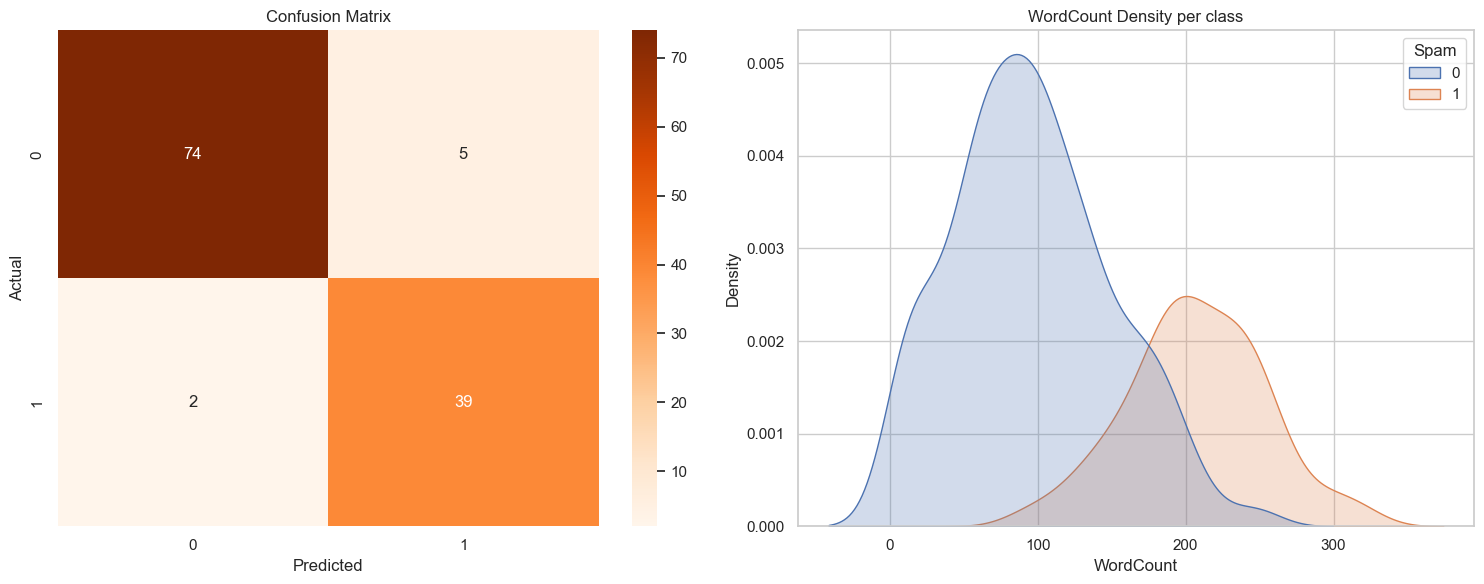

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Plot 2: Feature distributions per class
sns.kdeplot(data=df, x='WordCount', hue='Spam', fill=True, ax=axes[1])
axes[1].set_title("WordCount Density per class")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: Why is it called 'Naive'?**

*A: Because it naively assumes that all input features are completely independent of each other given the class label, which is rarely true in real life.*

**Q2: What is Laplacian Smoothing?**

*A: A technique to handle zero-probability outcomes. It adds a small value (alpha=1) to feature counts so that new unseen words do not zero out the entire conditional probability product.*

**Q3: When does Naive Bayes perform exceptionally well?**

*A: It performs very well in text classification (e.g. spam filtering, sentiment analysis) and high-dimensional sparse spaces.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What are the main types of Naive Bayes classifiers?**

*A: Gaussian (continuous features), Multinomial (text counts), and Bernoulli (binary indicators).*

**Q2: Does Naive Bayes require scale adjustments?**

*A: No, it computes class-conditional density statistics independently for each feature, so scaling has no effect.*

**Q3: What formula is it based on?**

*A: Bayes' Theorem: P(A|B) = P(B|A) * P(A) / P(B).*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.